Types of Data

• Identify which columns are categorical and which are numerical.

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [143]:
def mean(data):
    return round(sum(data)/len(data),2)

def median(data):
    sorted_data=sorted(data)
    
    if len(sorted_data)%2==0:
        first_value=sorted_data[len(sorted_data)//2 - 1]
        second_value=sorted_data[len(sorted_data)//2]
        return (first_value+second_value)/2
    else:
        value=sorted_data[len(sorted_data)//2]
        return sorted_data[value]
        
def mode(data):
    data=list(data)
    data_count_list=[]
    data_set=set(data)
    for i in data_set:
        data_count_list.append(data.count(i))

    data_list=list(data_set)

    if all(count==1 for count in data_count_list):
        return data_list[0]
    else:
        mode_value_index=data_count_list.index(max(data_count_list))
        return data_list[mode_value_index]

def range(data):
    return max(data)-min(data)

def variance(data):
    squared_diff=[]
    for i in data:
        squared_diff.append(round(pow(i-data.mean(),2),2))
    variance=round(sum(squared_diff),2)/len(data)
    return round(variance,2)

def standard_deviation(data):
    squared_diff=[]
    for i in data:
        squared_diff.append(round(pow(i-data.mean(),2),2))
    variance=round(sum(squared_diff),2)/len(data)
    std_of_data=math.sqrt(variance)
    std_of_data=round(std_of_data,2)
    return std_of_data

def skewness(data):
    # find mean
    mean=round(sum(data)/len(data),2)
    # find standard deviation
    squared_diff=[]
    for i in data:
        squared_diff.append(round(pow(i-mean,2),2))
    variance=round(sum(squared_diff),2)/len(data)
    std_of_data=math.sqrt(variance)
    std_of_data=round(std_of_data,2)
    # find difference between each data point and mean
    diff=[i-mean for i in data]
    # find cube of the difference between each data point and mean
    cube_diff=[i*i*i for i in diff]
    # find sum of the cube of the difference between each data point and mean
    sum_of_cube_diff=sum(cube_diff)
    # find skewness
    cube_of_standard_deviation=pow(std_of_data,3)
    return round(sum_of_cube_diff/(len(data)*cube_of_standard_deviation),3)

def kurtosis(data):
    # find mean
    mean=round(sum(data)/len(data),2)
    # find standard deviation
    squared_diff=[]
    for i in data:
        squared_diff.append(round(pow(i-mean,2),2))
    variance=round(sum(squared_diff),2)/len(data)
    std_of_data=math.sqrt(variance)
    std_of_data=round(std_of_data,2)
    # find the fourth power difference between each data point and mean and find its sum
    sum_of_fourth_power_diff=0
    for i in data:
        sum_of_fourth_power_diff+=pow(i-mean,4)/len(data)
    # mu4=sum_of_fourth_power_diff/len(data)
    # find the kurtosis
    kurtosis_value=round(sum_of_fourth_power_diff/pow(variance,2),2)
    return kurtosis_value-3

In [144]:
df=pd.read_csv("household_dataset.csv")

# filter categorical columns
categorical_columns=df.select_dtypes(include="object")

# filter numerical columns
numerical_columns=df.select_dtypes(include="integer")

print(f"Categorical Columns:{categorical_columns.columns}")
print(f"Numerical Columns:{numerical_columns.columns}")

Categorical Columns:Index(['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural'], dtype='object')
Numerical Columns:Index(['Age_of_Household_Head', 'Household_Income', 'Family_Size'], dtype='object')


Central Tendency

• Calculate Mean, Median, and Mode of Household Income and Age.
Interpret the central tendency and comment on income distribution.

In [145]:
household_income_mean=round(df["Household_Income"].mean(),2)
household_income_median=round(df["Household_Income"].median(),2)
household_income_mode=round(df["Household_Income"].mode(),2)

household_head_mean=round(df["Age_of_Household_Head"].mean(),2)
household_head_median=round(df["Age_of_Household_Head"].median(),2)
household_head_mode=round(df["Age_of_Household_Head"].mode(),2)

print(f"The mean of the household income is {household_income_mean}")
print(f"The median of the household income is {household_income_median}")
print(f"The mode of the household income is {household_income_mode[0]}")

print(f"The mean of the age of household head is {household_head_mean}")
print(f"The median of the age of household head is {household_head_median}")
print(f"The mode of the age of household head is {household_head_mode[0]}")

The mean of the household income is 51594.8
The median of the household income is 51909.0
The mode of the household income is 5301
The mean of the age of household head is 51.88
The median of the age of household head is 52.0
The mode of the age of household head is 68


Measures of Dispersion

• Calculate Range, Variance, and Standard Deviation of Household Income.

• Find IQR (Interquartile Range) and comment on income spread.

In [146]:
household_income_range=max(df["Household_Income"])-min(df["Household_Income"])
household_income_variance=round(df["Household_Income"].var(),2)
household_income_std=round(df["Household_Income"].std(),2)
print(f"The range of household income is {household_income_range}")
print(f"The variance of household income is {household_income_variance}")
print(f"The standard deviation of household income is {household_income_std}")

income_q1=df["Household_Income"].quantile(0.25)
income_q2=df["Household_Income"].quantile(0.5)
income_q3=df["Household_Income"].quantile(0.75)
income_IQR=income_q3-income_q1
print(f"The value of InterQuartile Range is {income_IQR}")

The range of household income is 94555
The variance of household income is 777522257.19
The standard deviation of household income is 27884.09
The value of InterQuartile Range is 45418.5


Distribution

• Plot a histogram of Household Income.

• Fit a Gaussian Normal Distribution curve.

• Calculate Skewness and Kurtosis of the income data.

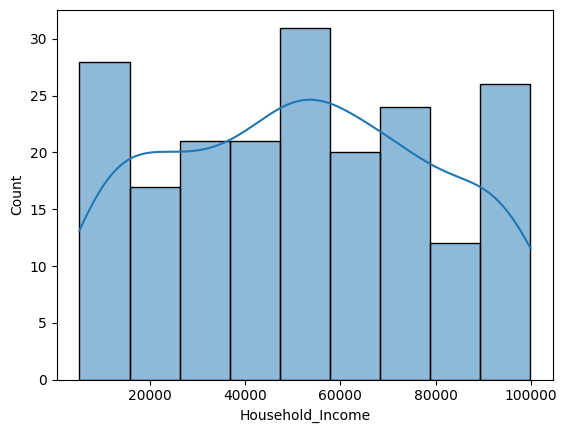

The skewness value of household income is 0.034
The kurtosis value of household income is -1.11


In [147]:
sns.histplot(df["Household_Income"],kde=True)
plt.show()

household_income_skewness=skewness(df["Household_Income"])
print(f"The skewness value of household income is {household_income_skewness}")

household_income_kurtosis=kurtosis(df["Household_Income"])
print(f"The kurtosis value of household income is {household_income_kurtosis}")

Data Categorization

• Use visualization (boxplot, histogram) to compare household income across
different education levels or urban/rural areas.

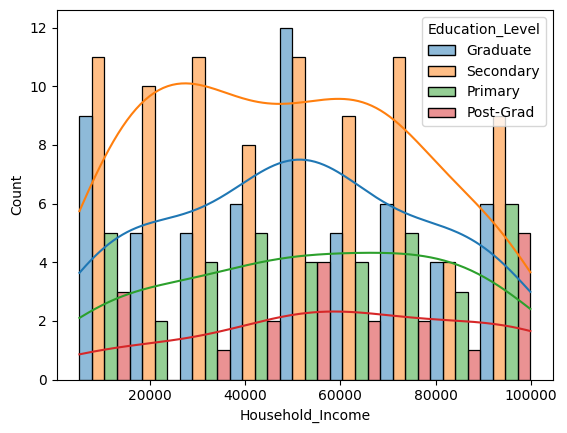

In [148]:
sns.histplot(x=df["Household_Income"],hue=df["Education_Level"],kde=True,multiple="dodge")
plt.show()

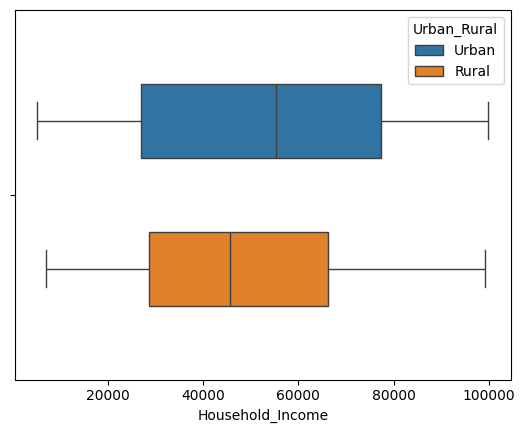

In [149]:
sns.boxplot(x=df["Household_Income"],hue=df["Urban_Rural"],gap=0.5)
plt.show()

Visualizations

• Histogram and KDE (Kernel Density Estimation) plot

• Boxplot comparing Family Size by Education Level

• Distribution Curve for Age vs. Income

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


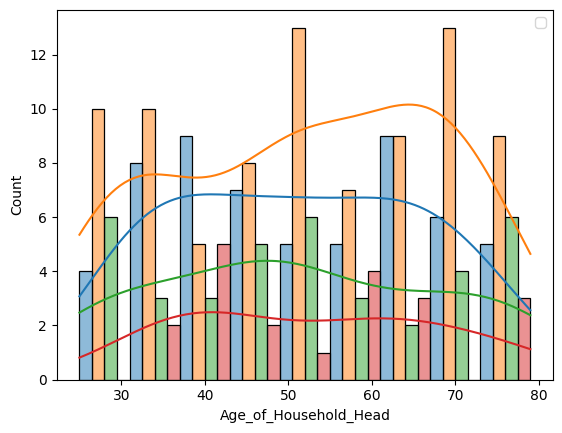

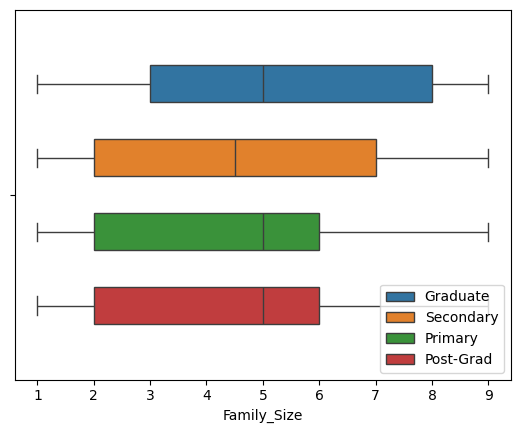

In [150]:
# histogram for comparing age vs income
sns.histplot(x=df["Age_of_Household_Head"],hue=df["Education_Level"],multiple="dodge",kde=True)
plt.legend(loc="upper right")
plt.show()

# boxplot for comparing family size by education level
sns.boxplot(x=df["Family_Size"],hue=df["Education_Level"],gap=0.5)
plt.legend(loc="lower right")
plt.show()

In [151]:
"""Conclusion on Household Income column's measure of central tendancy's concept's values"""
"""Most households earn around ₹51,500, but incomes vary widely. Many earn very little (like ₹5,300), while some earn much more, showing big income gaps."""

"""Conclusion on age of Household head based on its mean, median and mode's values"""
"""Most household heads are around 52, but many are older (68), showing two age groups dominate."""

"""Conclusion based on skewness value of household income column"""
"""The distribution is nearly symmetric (no strong left/right tail), meaning incomes are balanced around the mean."""

"""Conclusion based on kurtosis value of household income column"""
"""kurtosis value is -1.111, which means my distribution make the platykurtosis, which has fewer outliers than normal distribution """ 

'kurtosis value is -1.111, which means my distribution make the platykurtosis, which has fewer outliers than normal distribution '